# 6b. Baseline Modelling - CORRECTED (CatBoost Fix + Parent Feature Fix)

This notebook implements **baseline models** for revenue forecasting at the Business Subsegment level, organized in two main parts:

- **6.1 Time Series Models** - Classical TS approaches that operate on the raw Revenue/Orders series per subsegment.
- **6.2 Machine Learning Models** - ML models leveraging the full set of engineered features from Feature Selection.

---

**Target**: Revenue cons. (anon) - Orders used as leading indicator (not a target).  
**Granularity**: One model per TGL Business Subsegment (134 series).  
**Validation**: Train on periods 1–36, validate on 37–42 (6-period horizon).  
**Test**: Periods 43–48 (all targets NaN).  
**Metrics**: RMSE, MAE, wMAPE (weighted MAPE - robust to near-zero revenue subsegments), R² (coefficient of determination).  

**6.1 Time Series Models**: Naïve / Seasonal Naïve / Moving Average → SARIMA → VAR → Prophet → Chronos (zero-shot)  
**6.2 ML Models**: 

> **Note**: TS models (6.1) operate on the raw Revenue/Orders series per subsegment. Categorical columns serve as **grouping keys**. ML models (6.2) leverage the 100 engineered features from Feature Selection.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# REQUIRED PACKAGE INSTALLS
# Run this cell once to ensure all dependencies are available in your kernel.
# Safe to re-run - pip will skip already-installed packages.
# ─────────────────────────────────────────────────────────────────────────
import subprocess, sys

packages = [
    'lightgbm',       # Gradient boosting (LightGBM)
    'xgboost',        # Gradient boosting (XGBoost)
    'catboost',       # Gradient boosting (CatBoost) - also fixes clone() issue
    'pmdarima',       # SARIMA (auto_arima)
    'prophet',        # Facebook Prophet
    'statsmodels',    # VAR, ETS / Holt-Winters
    'scikit-learn',   # Ridge, Lasso, RandomForest, etc.
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'pyarrow',        # Parquet file reading
]

result = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '--quiet', '--upgrade'] + packages,
    capture_output=True, text=True
)
if result.returncode == 0:
    print('All packages installed / up-to-date')
else:
    print('Some packages failed to install:')
    print(result.stderr[-2000:])

All packages installed / up-to-date


In [ ]:
import os, sys
import time

from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb
import xgboost as xgb


# Register DLL directories BEFORE any heavy imports (fixes WinError 127 with torch on Windows)
if os.name == 'nt':
    _lib_bin = os.path.join(sys.prefix, 'Library', 'bin')
    if os.path.isdir(_lib_bin):
        os.environ['PATH'] = _lib_bin + os.pathsep + os.environ.get('PATH', '')
        if hasattr(os, 'add_dll_directory'):
            try: os.add_dll_directory(_lib_bin)
            except OSError: pass
    import importlib.util as _ilu
    _spec = _ilu.find_spec('torch')
    if _spec and _spec.origin:
        for _subdir in ('lib', 'bin'):
            _d = os.path.join(os.path.dirname(_spec.origin), _subdir)
            if os.path.isdir(_d):
                os.environ['PATH'] = _d + os.pathsep + os.environ.get('PATH', '')
                if hasattr(os, 'add_dll_directory'):
                    try: os.add_dll_directory(_d)
                    except OSError: pass

sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

# Sklearn - preprocessing pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import RobustScaler, OrdinalEncoder

# Baseline models
from src.code.baseline_models import *

%load_ext autoreload
%autoreload 2


print('All imports successful.')

All imports successful.


## 6.0 Data Loading

In [3]:
data_dir = '../data/features'

train_full = pd.read_parquet(os.path.join(data_dir, 'training_subsegment_fs.parquet'))
test_df    = pd.read_parquet(os.path.join(data_dir, 'validation_subsegment_fs.parquet'))

TARGET     = 'Revenue cons. (anon)'
ORDERS_COL = 'Orders cons. (anon)'
PERIOD_COL = 'Anon Period'
SUBSEG_COL = 'TGL Business Subsegment'
ID_COLS    = ['Anon Period', 'TGL Business Unit', 'TGL Business Segment', 'TGL Business Subsegment']

print(f'Training:   {train_full.shape}  |  Periods: {train_full[PERIOD_COL].min()}–{train_full[PERIOD_COL].max()}')
print(f'Test:       {test_df.shape}  |  Periods: {test_df[PERIOD_COL].min()}–{test_df[PERIOD_COL].max()}')
print(f'Unique subsegments: {train_full[SUBSEG_COL].nunique()}')

Training:   (4237, 110)  |  Periods: 1–42
Test:       (715, 110)  |  Periods: 43–48
Unique subsegments: 134


## 6.0.1 Internal Validation Split

The test set (periods 43–48) has all targets as NaN. We create an internal temporal split from training data:
- **Train**: periods 1–36
- **Validation**: periods 37–42 (mimics the 6-period test horizon)

In [ ]:
VAL_CUTOFF = 36
HORIZON    = 6

train_df = train_full[train_full[PERIOD_COL] <= VAL_CUTOFF].copy()
val_df   = train_full[train_full[PERIOD_COL] > VAL_CUTOFF].copy()

subsegments = get_valid_subsegments(train_df, TARGET)

# Series length diagnostics
lengths = [len(get_subsegment_series(train_df, s, PERIOD_COL, TARGET).dropna()) for s in subsegments]

print(f'Internal train: {train_df.shape} - periods {train_df[PERIOD_COL].min()}–{train_df[PERIOD_COL].max()}')
print(f'Internal val:   {val_df.shape} - periods {val_df[PERIOD_COL].min()}–{val_df[PERIOD_COL].max()}')
print(f'\nSubsegments with revenue data: {len(subsegments)}')
print(f'Series lengths - min: {min(lengths)}, median: {np.median(lengths):.0f}, max: {max(lengths)}')
print(f'Series with ≥ 24 points (seasonal SARIMA): {sum(l >= 24 for l in lengths)}')
print(f'Series with < 12 points: {sum(l < 12 for l in lengths)}')

Internal train: (3524, 110) — periods 1–36
Internal val:   (713, 110) — periods 37–42

Subsegments with revenue data: 117
Series lengths — min: 2, median: 36, max: 36
Series with ≥ 24 points (seasonal SARIMA): 93
Series with < 12 points: 12


---

## 6.1 Time Series Models

### 6.1.1 Naïve Baselines

Minimum performance bar - any model must beat these.

| Baseline | Logic |
|----------|-------|
| **Naïve** | $\hat{y}_t = y_{t-1}$ |
| **Seasonal Naïve** | $\hat{y}_t = y_{t-12}$ |
| **Moving Average** | $\hat{y}_t = \text{mean}(y_{t-1}, ..., y_{t-k})$ |

In [ ]:
naive_all = run_naive_baselines(subsegments, train_df, val_df, PERIOD_COL, TARGET)

baseline_metrics = []
for name, res in naive_all.items():
    metrics = evaluate_model(res, val_df, PERIOD_COL, TARGET, name)
    baseline_metrics.append(metrics)
    print(f"{name:20s} - RMSE: {metrics['RMSE']:>14,.0f} | MAE: {metrics['MAE']:>14,.0f} | wMAPE: {metrics['wMAPE']:.1f}%")

print(f'\nBaselines computed for {len(naive_all["Naïve"])} subsegments.')

Naïve                — RMSE:     20,881,478 | MAE:      9,968,088 | wMAPE: 26.0%
Seasonal Naïve       — RMSE:     12,800,528 | MAE:      5,346,114 | wMAPE: 14.0%
Moving Avg (3)       — RMSE:     11,403,219 | MAE:      5,406,896 | wMAPE: 14.1%
Moving Avg (6)       — RMSE:      9,709,532 | MAE:      4,588,482 | wMAPE: 12.0%

Baselines computed for 110 subsegments.


---

### 6.1.2 SARIMA

SARIMA models a single univariate series per subsegment. Uses `pmdarima.auto_arima` for automatic $(p,d,q)×(P,D,Q,m)$ selection.  
Seasonal period m=12 if ≥24 data points.

$\phi(B)\Phi(B^{12})(1-B)^d(1-B^{12})^D y_t = \theta(B)\Theta(B^{12})\epsilon_t$

In [ ]:
sarima_results, sarima_errors = run_sarima(subsegments, train_df, val_df, PERIOD_COL, TARGET)

sarima_metrics = evaluate_model(sarima_results, val_df, PERIOD_COL, TARGET, 'SARIMA')
print(f"SARIMA - RMSE: {sarima_metrics['RMSE']:,.0f} | MAE: {sarima_metrics['MAE']:,.0f} | wMAPE: {sarima_metrics['wMAPE']:.1f}% | R²: {sarima_metrics['R2']:.4f}")

  SARIMA progress: 25/117 subsegments...
  SARIMA progress: 50/117 subsegments...
  SARIMA progress: 75/117 subsegments...
  SARIMA progress: 100/117 subsegments...

SARIMA fitted for 105 subsegments. Errors: 2
SARIMA — RMSE: 14,780,721 | MAE: 5,944,247 | wMAPE: 15.4% | R²: 0.9538


---

### 6.1.3 VAR - Vector Autoregression

VAR captures the interaction between Revenue and Orders (leading indicator).

$\mathbf{y}_t = \mathbf{c} + \sum_{i=1}^{p} \mathbf{A}_i \mathbf{y}_{t-i} + \mathbf{u}_t \quad \text{where } \mathbf{y}_t = [\text{Revenue}_t, \text{Orders}_t]^\top$

In [ ]:
var_results, var_errors = run_var(subsegments, train_df, val_df, PERIOD_COL, TARGET, ORDERS_COL)

var_metrics = evaluate_model(var_results, val_df, PERIOD_COL, TARGET, 'VAR')
print(f"VAR - RMSE: {var_metrics['RMSE']:,.0f} | MAE: {var_metrics['MAE']:,.0f} | wMAPE: {var_metrics['wMAPE']:.1f}% | R²: {var_metrics['R2']:.4f}")

  VAR progress: 25/117 subsegments...
  VAR progress: 50/117 subsegments...
  VAR progress: 75/117 subsegments...
  VAR progress: 100/117 subsegments...

VAR fitted for 89 subsegments. Errors: 11
VAR — RMSE: 16,254,747 | MAE: 7,348,745 | wMAPE: 16.2% | R²: 0.9493


---

### 6.1.4 Facebook Prophet

Auto-decomposes series into trend + seasonality.  
`changepoint_prior_scale=0.01` to reduce overfitting (professor's advice).

$y(t) = g(t) + s(t) + h(t) + \epsilon_t$

In [ ]:
prophet_results, prophet_errors = run_prophet(subsegments, train_df, val_df, PERIOD_COL, TARGET)

prophet_metrics = evaluate_model(prophet_results, val_df, PERIOD_COL, TARGET, 'Prophet')
print(f"Prophet - RMSE: {prophet_metrics['RMSE']:,.0f} | MAE: {prophet_metrics['MAE']:,.0f} | wMAPE: {prophet_metrics['wMAPE']:.1f}% | R²: {prophet_metrics['R2']:.4f}")

  Prophet progress: 25/117 subsegments...
  Prophet progress: 50/117 subsegments...
  Prophet progress: 75/117 subsegments...
  Prophet progress: 100/117 subsegments...

Prophet fitted for 107 subsegments. Errors: 0
Prophet — RMSE: 11,892,845 | MAE: 5,699,949 | wMAPE: 14.7% | R²: 0.9696


---

### 6.1.5 Amazon Chronos (Zero-Shot Transformer)

Foundation model pre-trained on millions of time series - **no training needed**. We feed each subsegment's history and get forecasts. Uses mazon/chronos-t5-small.

> ⚠️ Requires PyTorch. If torch has DLL issues in your conda environment, this section will be skipped gracefully.

In [9]:
'''chronos_results, chronos_errors = run_chronos(subsegments, train_df, val_df, PERIOD_COL, TARGET)

if chronos_results:
    chronos_metrics = evaluate_model(chronos_results, val_df, PERIOD_COL, TARGET, 'Chronos (Zero-Shot)')
    print(f"Chronos - RMSE: {chronos_metrics['RMSE']:,.0f} | MAE: {chronos_metrics['MAE']:,.0f} | wMAPE: {chronos_metrics['wMAPE']:.1f}% | R²: {chronos_metrics['R2']:.4f}")
else:
    chronos_metrics = {'Model': 'Chronos (Zero-Shot)', 'RMSE': np.nan, 'MAE': np.nan, 'wMAPE': np.nan, 'R2': np.nan}
    print('Chronos skipped - see errors above.') '''

'chronos_results, chronos_errors = run_chronos(subsegments, train_df, val_df, PERIOD_COL, TARGET)\n\nif chronos_results:\n    chronos_metrics = evaluate_model(chronos_results, val_df, PERIOD_COL, TARGET, \'Chronos (Zero-Shot)\')\n    print(f"Chronos - RMSE: {chronos_metrics[\'RMSE\']:,.0f} | MAE: {chronos_metrics[\'MAE\']:,.0f} | wMAPE: {chronos_metrics[\'wMAPE\']:.1f}% | R²: {chronos_metrics[\'R2\']:.4f}")\nelse:\n    chronos_metrics = {\'Model\': \'Chronos (Zero-Shot)\', \'RMSE\': np.nan, \'MAE\': np.nan, \'wMAPE\': np.nan, \'R2\': np.nan}\n    print(\'Chronos skipped - see errors above.\') '

---

### 6.1.6 ETS - Exponential Smoothing (Holt-Winters)

ETS decomposes each series into **Error + Trend + Seasonality** with exponentially decaying weights.
More flexible than Moving Average because it automatically learns the weight of recent periods.

$$y_t = \ell_{t-1} + b_{t-1} + s_{t-m} + \epsilon_t$$

where $\ell$ is the level, $b$ the trend, and $s$ the seasonal component with period $m=12$.

In [ ]:
ets_results, ets_errors = run_ets(subsegments, train_df, val_df, PERIOD_COL, TARGET)

ets_metrics = evaluate_model(ets_results, val_df, PERIOD_COL, TARGET, 'ETS (Holt-Winters)')
print(f"ETS - RMSE: {ets_metrics['RMSE']:,.0f} | MAE: {ets_metrics['MAE']:,.0f} | wMAPE: {ets_metrics['wMAPE']:.1f}% | R²: {ets_metrics['R2']:.4f}")    

  ETS progress: 25/117 subsegments...
  ETS progress: 50/117 subsegments...
  ETS progress: 75/117 subsegments...
  ETS progress: 100/117 subsegments...
  ETS done. Errors: 0/117
ETS — RMSE: 13,759,376 | MAE: 5,903,635 | wMAPE: 15.4% | R²: 0.9590


---

### 6.1.6 Time Series Model Comparison

In [ ]:
# all_metrics = baseline_metrics + [sarima_metrics, var_metrics, ets_metrics, prophet_metrics, chronos_metrics]
all_metrics = baseline_metrics + [sarima_metrics, var_metrics, ets_metrics, prophet_metrics]

comparison_df = pd.DataFrame(all_metrics)[['Model', 'RMSE', 'MAE', 'wMAPE', 'R2']]
comparison_df = comparison_df.sort_values('RMSE').reset_index(drop=True)

print('=' * 72)
print('MODEL COMPARISON - Validation (Periods 37–42)')
print('=' * 72)

comparison_df.style.format(
    {'RMSE': '{:,.0f}', 'MAE': '{:,.0f}', 'wMAPE': '{:.1f}%', 'R2': '{:.4f}'}
).highlight_min(subset=['RMSE', 'MAE', 'wMAPE'], color='green').highlight_max(subset=['R2'], color='green')

MODEL COMPARISON — Validation (Periods 37–42)


,Model,RMSE,MAE,wMAPE,R2
0,Moving Avg (6),"9,709,532","4,588,482",12.0%,0.9796
1,Moving Avg (3),"11,403,219","5,406,896",14.1%,0.9719
2,Prophet,"11,892,845","5,699,949",14.7%,0.9696
3,Seasonal Naïve,"12,800,528","5,346,114",14.0%,0.9645
4,ETS (Holt-Winters),"13,759,376","5,903,635",15.4%,0.9590
5,SARIMA,"14,780,721","5,944,247",15.4%,0.9538
6,VAR,"16,254,747","7,348,745",16.2%,0.9493
7,Naïve,"20,881,478","9,968,088",26.0%,0.9056


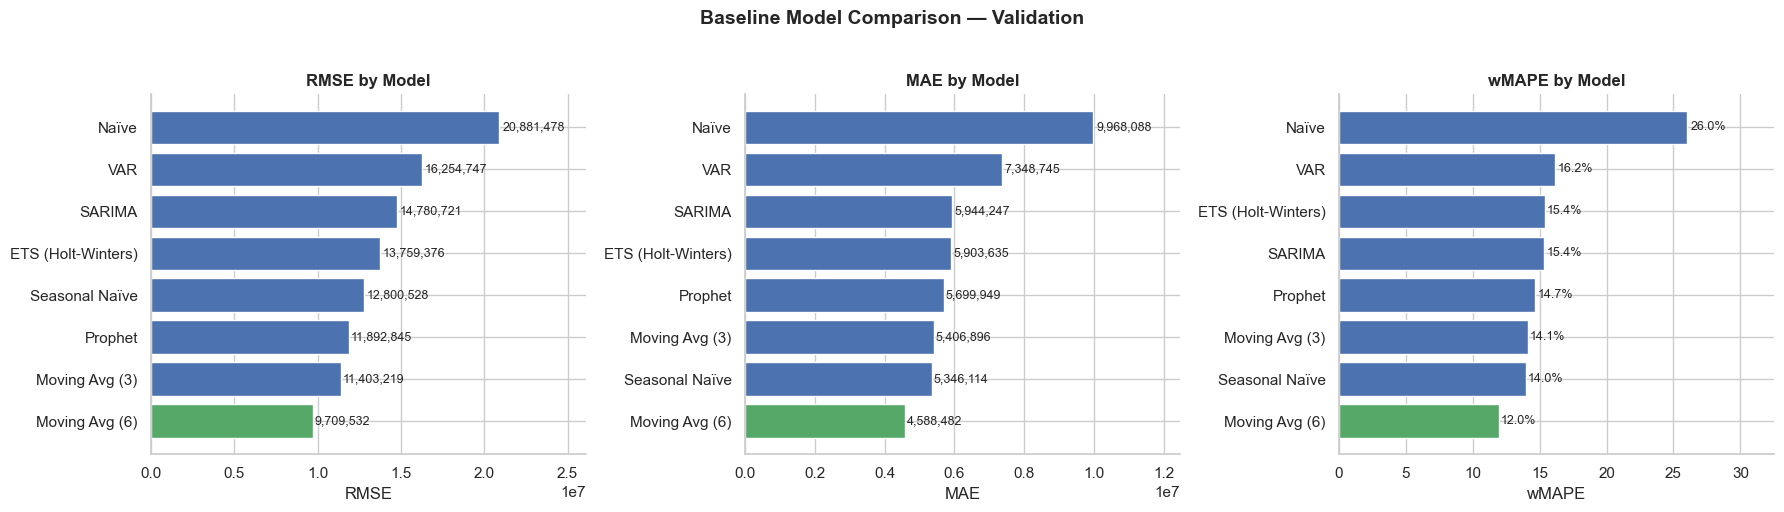

In [12]:
plot_model_comparison(comparison_df)

#### Actual vs Predicted - Representative Subsegments

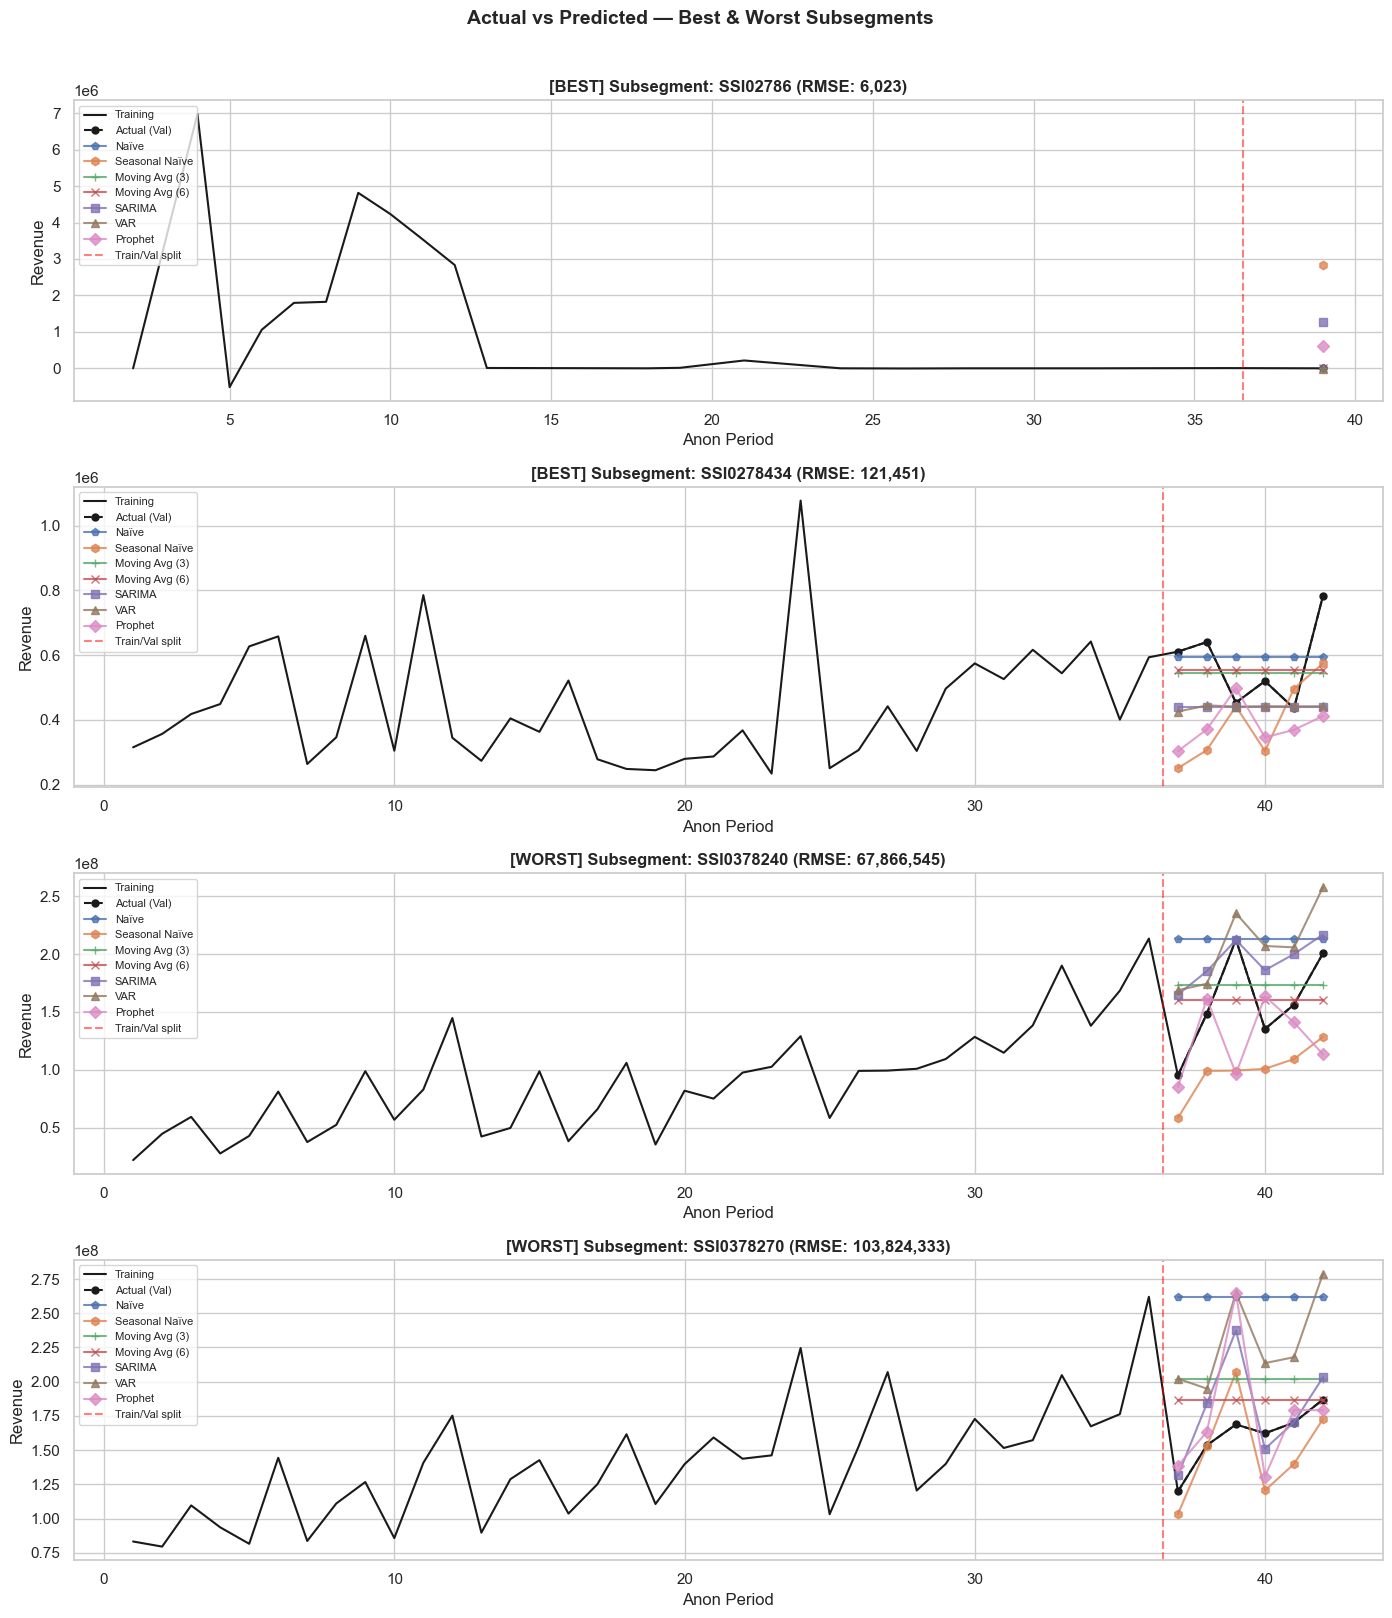

In [13]:
# Combine all model results for the comparison plot
all_results = {}
all_results.update(naive_all)  # Naïve, Seasonal Naïve, Moving Avg (3), Moving Avg (6)
all_results['SARIMA'] = sarima_results
all_results['VAR'] = var_results
all_results['Prophet'] = prophet_results
#if chronos_results:
#    all_results['Chronos (Zero-Shot)'] = chronos_results

plot_actual_vs_predicted(all_results, train_full, val_df, PERIOD_COL, TARGET, VAL_CUTOFF)

---

### 6.1.7 Baseline Summary

- **Naïve baselines** establish the minimum performance bar
- **SARIMA** models univariate seasonal patterns per subsegment
- **VAR** captures Revenue–Orders lead-lag dynamics (bivariate)
- **Prophet** auto-decomposes trend + seasonality
- **Chronos** provides zero-shot forecasting from a pre-trained transformer

> ℹ️ These baselines are **univariate/bivariate** — they do not use the full 100-feature set. The next section prepares the pipeline for ML models that leverage all features.

In [14]:
print('\n' + '=' * 72)
print('FINAL BASELINE RESULTS')
print('=' * 72)
print(comparison_df.to_string(index=False))
print(f'\nBest model by RMSE: {comparison_df.iloc[0]["Model"]}')


FINAL BASELINE RESULTS
             Model         RMSE          MAE     wMAPE       R2
    Moving Avg (6) 9.709532e+06 4.588482e+06 11.973316 0.979592
    Moving Avg (3) 1.140322e+07 5.406896e+06 14.108909 0.971852
           Prophet 1.189285e+07 5.699949e+06 14.687430 0.969646
    Seasonal Naïve 1.280053e+07 5.346114e+06 13.950303 0.964531
ETS (Holt-Winters) 1.375938e+07 5.903635e+06 15.405114 0.959018
            SARIMA 1.478072e+07 5.944247e+06 15.356445 0.953758
               VAR 1.625475e+07 7.348745e+06 16.162206 0.949301
             Naïve 2.088148e+07 9.968088e+06 26.011013 0.905611

Best model by RMSE: Moving Avg (6)


---

## 6.2 Machine Learning Models

This section benchmarks ML models for revenue forecasting using **recursive multi-step prediction** to avoid data leakage.

**Key design decisions:**
- **Orders/ASP features dropped** — the test set (periods 43–48) has neither Orders nor Revenue, so any feature derived from these is unusable at inference time.
- **Recursive forecasting** — lag features are recomputed at each prediction step using only past actuals + previous predictions. Direct prediction with pre-computed lags would leak future Revenue values through the lag columns.
- **Two hierarchy levels** — Subsegment (bottom-up, ~100 series) and Segment (middle-out, ~24 series).

---
### 6.2.0 Imports & Configuration

In [15]:
from src.code.functions_models_v2 import *  # CORRECTED: CatBoost + parent-feature fixes

# Column aliases (from defaults in functions_models.py)
TARGET     = DEFAULT_TARGET
ORDERS_COL = DEFAULT_ORDERS_COL
PERIOD_COL = DEFAULT_PERIOD_COL
SUBSEG_COL = DEFAULT_SUBSEG_COL
SEG_COL    = DEFAULT_SEG_COL
BU_COL     = DEFAULT_BU_COL

VAL_CUTOFF = 36   # Train: periods 1-36, Validation: periods 37-42
HORIZON    = 6    # 6-period forecast horizon (matches test set)

print(f'Train:      periods 1-{VAL_CUTOFF}')
print(f'Validation: periods {VAL_CUTOFF+1}-{VAL_CUTOFF+HORIZON}')
print(f'Test:       periods 43-48 (targets unknown)')

Train:      periods 1-36
Validation: periods 37-42
Test:       periods 43-48 (targets unknown)


### 6.2.1. Direct Multi-Step Forecasting

In [23]:
# ─────────────────────────────────────────────────────────────────────────
# 6.2.1 DIRECT MULTI-STEP FORECASTING (MULTIPLE MODELS)
# ─────────────────────────────────────────────────────────────────────────
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

# 1. Define the features to use
FEATURES = [col for col in train_full.columns if col not in ID_COLS + [TARGET, ORDERS_COL]]

# 2. Define the models to be evaluated
# Note: We wrap Ridge and RandomForest in a Pipeline with SimpleImputer to handle potential NaNs
models_dict = {
    'Ridge (Linear)': Pipeline([
        ('imputer', SimpleImputer(strategy='median')), 
        ('model', Ridge(alpha=1.0, random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')), 
        ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    ]),
    'XGBoost': xgb.XGBRegressor(n_estimators=150, max_depth=5, learning_rate=0.05, random_state=42, n_jobs=-1),
    'LightGBM': lgb.LGBMRegressor(n_estimators=150, max_depth=5, learning_rate=0.05, random_state=42, n_jobs=-1, verbose=-1),
    'CatBoost': cb.CatBoostRegressor(iterations=150, depth=5, learning_rate=0.05, random_state=42, verbose=0)
}

trained_models = {name: {} for name in models_dict.keys()}
val_predictions_list = []

print("=== Starting Direct Multi-Step Training for Multiple Models ===")

for step in range(1, HORIZON + 1):
    print(f"\n--- Preparing Data for Step {step} (Horizon: t+{step}) ---")
    
    # Copy the full dataset and sort it
    df_step = train_full.copy()
    df_step = df_step.sort_values(by=[SUBSEG_COL, PERIOD_COL])
    
    # Shift the target backwards
    target_step_col = f'{TARGET}_lead_{step}'
    df_step[target_step_col] = df_step.groupby(SUBSEG_COL)[TARGET].shift(-step)
    
    # Fix infinites
    df_step[target_step_col] = df_step[target_step_col].replace([np.inf, -np.inf], np.nan)
    
    # Define Train and Validation sets AND DROP NaNs
    train_step_df = df_step[df_step[PERIOD_COL] <= (VAL_CUTOFF - step)].copy()
    train_step_df = train_step_df.dropna(subset=[target_step_col])
    
    val_step_df = df_step[df_step[PERIOD_COL] == VAL_CUTOFF].copy()
    val_step_df = val_step_df.dropna(subset=[target_step_col])
    
    X_train = train_step_df[FEATURES]
    y_train = train_step_df[target_step_col]
    
    X_val = val_step_df[FEATURES]
    y_val = val_step_df[target_step_col]
    
    # Train each model for this step
    for model_name, model_instance in models_dict.items():
        # Clone ensures we start with a fresh, untrained model each time
        model = clone(model_instance)
        
        # Fit the model
        model.fit(X_train, y_train)
        
        # Store the trained model
        trained_models[model_name][step] = model
        
        # Generate predictions
        preds = model.predict(X_val)
        
        # Store results for this specific model and step
        temp_val_df = val_step_df[[SUBSEG_COL, PERIOD_COL]].copy()
        temp_val_df['Actual'] = y_val
        temp_val_df['Prediction'] = preds
        temp_val_df['Forecast_Period'] = temp_val_df[PERIOD_COL] + step 
        temp_val_df['Model'] = model_name
        
        val_predictions_list.append(temp_val_df)
        
    print(f"All models trained for t+{step}. (Train: {len(X_train)} | Val: {len(X_val)} samples)")

# Combine all predictions
all_val_preds = pd.concat(val_predictions_list, ignore_index=True)
print("\n=== All Models Trained Successfully! ===")

=== Starting Direct Multi-Step Training for Multiple Models ===

--- Preparing Data for Step 1 (Horizon: t+1) ---
All models trained for t+1. (Train: 3410 | Val: 106 samples)

--- Preparing Data for Step 2 (Horizon: t+2) ---
All models trained for t+2. (Train: 3296 | Val: 105 samples)

--- Preparing Data for Step 3 (Horizon: t+3) ---
All models trained for t+3. (Train: 3180 | Val: 105 samples)

--- Preparing Data for Step 4 (Horizon: t+4) ---
All models trained for t+4. (Train: 3068 | Val: 105 samples)

--- Preparing Data for Step 5 (Horizon: t+5) ---
All models trained for t+5. (Train: 2960 | Val: 104 samples)

--- Preparing Data for Step 6 (Horizon: t+6) ---
All models trained for t+6. (Train: 2851 | Val: 102 samples)

=== All Models Trained Successfully! ===


In [25]:
# ─────────────────────────────────────────────────────────────────────────
# 6.2.2 EVALUATE MULTI-STEP ML MODELS
# ─────────────────────────────────────────────────────────────────────────
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

results = []

# Evaluate each model independently
for model_name, group in all_val_preds.groupby('Model'):
    
    # Drop rows where 'Actual' might be NaN
    eval_df = group.dropna(subset=['Actual'])
    
    if len(eval_df) == 0:
        continue
        
    rmse = np.sqrt(mean_squared_error(eval_df['Actual'], eval_df['Prediction']))
    mae = mean_absolute_error(eval_df['Actual'], eval_df['Prediction'])
    r2 = r2_score(eval_df['Actual'], eval_df['Prediction'])
    
    # Calculate wMAPE
    sum_errors = np.sum(np.abs(eval_df['Actual'] - eval_df['Prediction']))
    sum_actuals = np.sum(np.abs(eval_df['Actual']))
    wmape = (sum_errors / sum_actuals) * 100 if sum_actuals != 0 else np.nan
    
    results.append({
        'Model': model_name,
        'RMSE': rmse,
        'MAE': mae,
        'wMAPE (%)': wmape,
        'R²': r2
    })

# Convert to DataFrame and sort by wMAPE
results_df = pd.DataFrame(results).sort_values(by='wMAPE (%)').reset_index(drop=True)

# Format the numerical columns for better readability
format_dict = {
    'RMSE': '{:,.0f}',
    'MAE': '{:,.0f}',
    'wMAPE (%)': '{:.2f}%',
    'R²': '{:.4f}'
}

print('========================================================================')
print('DIRECT MULTI-STEP ML MODELS — Validation Metrics (Periods 37-42)')
print('========================================================================')

# Display formatted table
display(results_df.style.format(format_dict).hide(axis='index'))

DIRECT MULTI-STEP ML MODELS — Validation Metrics (Periods 37-42)


Model,RMSE,MAE,wMAPE (%),R²
XGBoost,"11,618,730","5,281,580",13.65%,0.9710
LightGBM,"12,161,952","5,304,662",13.71%,0.9682
CatBoost,"10,504,311","5,620,634",14.53%,0.9763
RandomForest,"13,630,128","5,981,415",15.46%,0.9600
Ridge (Linear),"10,678,888","6,617,635",17.11%,0.9755


---

### 6.2.3 XGBoost — Hyperparameter Tuning (Optuna)

The baseline XGBoost uses conservative defaults (`n_estimators=150, max_depth=5, lr=0.05`).
Here we run a **time-series–safe Optuna search** to find better hyperparameters:

- **Search space**: `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `min_child_weight`, `gamma`, `reg_alpha`, `reg_lambda`
- **CV strategy**: walk-forward split on the training set (no look-ahead leakage)
- **Objective**: minimise wMAPE on the internal validation fold
- **Evaluation**: retrain best params on full train 1–36, evaluate on val 37–42 (direct multi-step)

> **Target to beat**: Moving Avg (6) $\rightarrow$ RMSE 9,709,532 | wMAPE 12.0%

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# XGBoost — Optuna Hyperparameter Tuning (time-series safe)
# ─────────────────────────────────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '--quiet', 'optuna'], check=False)

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

# ── Constants (already defined above, repeated for clarity) ──────────────────
_BASELINE_WMAPE = 12.0   # Moving Avg (6)
_BASELINE_RMSE  = 9_709_532

N_TRIALS   = 60   # increase for more thorough search (costs time)
CV_SPLITS  = 3    # walk-forward folds inside the training set
HORIZON    = 6

# ── wMAPE helper ─────────────────────────────────────────────────────────────
def wmape(y_true, y_pred):
    denom = np.sum(np.abs(y_true))
    return (np.sum(np.abs(y_true - y_pred)) / denom * 100) if denom > 0 else np.nan

# ─────────────────────────────────────────────────────────────────────────────
# Step 1 – build walk-forward CV fold boundaries inside training periods 1-36
# ─────────────────────────────────────────────────────────────────────────────
all_periods = sorted(train_df[PERIOD_COL].unique())  # 1 … 36
fold_size   = len(all_periods) // (CV_SPLITS + 1)

folds = []
for k in range(CV_SPLITS):
    train_end = all_periods[(k + 1) * fold_size - 1]
    val_end   = all_periods[min((k + 2) * fold_size - 1, len(all_periods) - 1)]
    folds.append((train_end, val_end))
    print(f"  Fold {k+1}: train ≤ period {train_end}  |  val period {train_end+1}–{val_end}")

# ─────────────────────────────────────────────────────────────────────────────
# Step 2 – Optuna objective: direct multi-step, averaged over CV folds & steps
# ─────────────────────────────────────────────────────────────────────────────
def objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int  ('n_estimators',      100, 600),
        max_depth         = trial.suggest_int  ('max_depth',          3,  8),
        learning_rate     = trial.suggest_float('learning_rate',      0.01, 0.3, log=True),
        subsample         = trial.suggest_float('subsample',          0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree',   0.5, 1.0),
        min_child_weight  = trial.suggest_int  ('min_child_weight',   1,  20),
        gamma             = trial.suggest_float('gamma',              0.0, 5.0),
        reg_alpha         = trial.suggest_float('reg_alpha',          1e-4, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda',         1e-4, 10.0, log=True),
        random_state      = 42,
        n_jobs            = -1,
        tree_method       = 'hist',
    )

    fold_wmapes = []

    for (tr_end, vl_end) in folds:
        step_wmapes = []
        for step in range(1, HORIZON + 1):
            df_s = train_full.copy().sort_values([SUBSEG_COL, PERIOD_COL])
            lead_col = f'{TARGET}_lead_{step}'
            df_s[lead_col] = df_s.groupby(SUBSEG_COL)[TARGET].shift(-step)
            df_s[lead_col] = df_s[lead_col].replace([np.inf, -np.inf], np.nan)

            # train slice: periods up to tr_end - step (avoid leakage from the shift)
            train_s = df_s[df_s[PERIOD_COL] <= (tr_end - step)].dropna(subset=[lead_col])
            val_s   = df_s[df_s[PERIOD_COL] == tr_end         ].dropna(subset=[lead_col])

            if len(train_s) < 10 or len(val_s) == 0:
                continue

            model = xgb.XGBRegressor(**params)
            model.fit(
                train_s[FEATURES], train_s[lead_col],
                eval_set=[(val_s[FEATURES], val_s[lead_col])],
                verbose=False,
            )
            preds = model.predict(val_s[FEATURES])
            step_wmapes.append(wmape(val_s[lead_col].values, preds))

        if step_wmapes:
            fold_wmapes.append(np.mean(step_wmapes))

    return np.mean(fold_wmapes) if fold_wmapes else float('inf')

# ─────────────────────────────────────────────────────────────────────────────
# Step 3 – Run search
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n-> Running Optuna search — {N_TRIALS} trials × {CV_SPLITS} CV folds …")
study = optuna.create_study(direction='minimize',
                             sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

best_params = study.best_params
best_params.update({'random_state': 42, 'n_jobs': -1, 'tree_method': 'hist'})
print(f"\n-> Best CV wMAPE: {study.best_value:.2f}%")
print(f"   Best params: {best_params}")

# ─────────────────────────────────────────────────────────────────────────────
# Step 4 – Retrain on full train 1–36, evaluate on val 37–42
# ─────────────────────────────────────────────────────────────────────────────
print("\n-> Retraining tuned XGBoost on full training set (1-36) …")
tuned_val_preds = []
tuned_trained_models = {}

for step in range(1, HORIZON + 1):
    df_s = train_full.copy().sort_values([SUBSEG_COL, PERIOD_COL])
    lead_col = f'{TARGET}_lead_{step}'
    df_s[lead_col] = df_s.groupby(SUBSEG_COL)[TARGET].shift(-step)
    df_s[lead_col] = df_s[lead_col].replace([np.inf, -np.inf], np.nan)

    train_s   = df_s[df_s[PERIOD_COL] <= (VAL_CUTOFF - step)].dropna(subset=[lead_col])
    val_s     = df_s[df_s[PERIOD_COL] == VAL_CUTOFF          ].dropna(subset=[lead_col])

    model = xgb.XGBRegressor(**best_params)
    model.fit(train_s[FEATURES], train_s[lead_col], verbose=False)
    tuned_trained_models[step] = model

    preds = model.predict(val_s[FEATURES])
    tmp   = val_s[[SUBSEG_COL, PERIOD_COL]].copy()
    tmp['Actual']         = val_s[lead_col].values
    tmp['Prediction']     = preds
    tmp['Forecast_Period']= tmp[PERIOD_COL] + step
    tuned_val_preds.append(tmp)

tuned_df = pd.concat(tuned_val_preds, ignore_index=True).dropna(subset=['Actual'])

# ─────────────────────────────────────────────────────────────────────────────
# Step 5 – Metrics & comparison
# ─────────────────────────────────────────────────────────────────────────────
rmse_tuned  = np.sqrt(mean_squared_error(tuned_df['Actual'], tuned_df['Prediction']))
mae_tuned   = np.mean(np.abs(tuned_df['Actual'] - tuned_df['Prediction']))
wmape_tuned = wmape(tuned_df['Actual'].values, tuned_df['Prediction'].values)
r2_tuned    = 1 - np.sum((tuned_df['Actual'] - tuned_df['Prediction'])**2) / \
                  np.sum((tuned_df['Actual'] - tuned_df['Actual'].mean())**2)

baseline_xgb_wmape = 13.65   # from cell 31 output

summary = pd.DataFrame([
    {'Model': 'Moving Avg (6) [baseline]',   'RMSE': 9_709_532, 'wMAPE (%)': 12.00, 'R²': 0.9796},
    {'Model': 'XGBoost (default)',            'RMSE': 11_618_730,'wMAPE (%)': baseline_xgb_wmape,'R²': 0.9710},
    {'Model': 'XGBoost (Optuna-tuned)',       'RMSE': rmse_tuned, 'wMAPE (%)': wmape_tuned, 'R²': r2_tuned},
])

print("\n" + "="*60)
print("  TUNED XGBoost vs Baselines - Validation (Periods 37-42)")
print("="*60)
display(summary.style.format({'RMSE': '{:,.0f}', 'wMAPE (%)': '{:.2f}%', 'R²': '{:.4f}'})
                      .hide(axis='index')
                      .highlight_min(subset=['RMSE', 'wMAPE (%)'], color='#d4edda')
                      .highlight_max(subset=['R²'], color='#d4edda'))

beat_baseline = wmape_tuned < _BASELINE_WMAPE
print(f"\n{'->  Tuned XGBoost BEATS Moving Avg (6)! wMAPE: {wmape_tuned:.2f}% < {_BASELINE_WMAPE:.2f}%' if beat_baseline else f'->  Still below baseline. wMAPE: {wmape_tuned:.2f}% vs {_BASELINE_WMAPE:.2f}%'}")


  Fold 1: train ≤ period 9  |  val period 10–18
  Fold 2: train ≤ period 18  |  val period 19–27
  Fold 3: train ≤ period 27  |  val period 28–36

-> Running Optuna search — 60 trials × 3 CV folds …


  0%|          | 0/60 [00:00<?, ?it/s]


-> Best CV wMAPE: 17.35%
   Best params: {'n_estimators': 376, 'max_depth': 8, 'learning_rate': 0.013599251318137256, 'subsample': 0.5215186861135771, 'colsample_bytree': 0.6860019145788417, 'min_child_weight': 2, 'gamma': 3.2881110884130225, 'reg_alpha': 1.3713344447076126, 'reg_lambda': 0.00040461336462689027, 'random_state': 42, 'n_jobs': -1, 'tree_method': 'hist'}

-> Retraining tuned XGBoost on full training set (1-36) …

  TUNED XGBoost vs Baselines - Validation (Periods 37-42)


Model,RMSE,wMAPE (%),R²
Moving Avg (6) [baseline],"9,709,532",12.00%,0.9796
XGBoost (default),"11,618,730",13.65%,0.9710
XGBoost (Optuna-tuned),"11,184,524",13.53%,0.9731



->  Still below baseline. wMAPE: 13.53% vs 12.00%


## 6.3. Final Prediction on Test Set 

In [34]:
# ──────────────────────────────────────────────────────────────────────────────
# FINAL BLIND PREDICTION ON TEST SET (Periods 43-48)
# ──────────────────────────────────────────────────────────────────────────────
# Moving Average (6) had the best results on the validation set, so we use it 
# as our final predictor for the test set.

last_known_period = 42

print("=== Generating Final Forecasts for Test Set (Periods 43-48) ===")

BEST_MODEL_NAME = "Moving Avg (6)"
print(f"Using {BEST_MODEL_NAME} as the final predictor.")

final_predictions = []
window = 6

# Get all unique subsegments from train_full
subsegments = train_full[SUBSEG_COL].unique()

for seg in subsegments:
    # Isolate the target series for the subsegment up to the last known period (42)
    train_s = get_subsegment_series(
        train_full[train_full[PERIOD_COL] <= last_known_period], 
        seg, 
        PERIOD_COL, 
        TARGET
    ).dropna()
    
    # Compute moving average (6) forecast if we have data, else use 0
    if len(train_s) > 0:
        preds = moving_average_forecast(train_s, horizon=HORIZON, window=window)
    else:
        preds = np.zeros(HORIZON)
        
    for step in range(1, HORIZON + 1):
        forecast_period = last_known_period + step
        final_predictions.append({
            SUBSEG_COL: seg,
            PERIOD_COL: forecast_period,
            "Forecast": preds[step-1],
            "Model": f"{BEST_MODEL_NAME} (Multi-Step t+{step})"
        })

# Combine into the final dataframe
final_test_predictions = pd.DataFrame(final_predictions)

# Sort by subsegment and period for better readability
final_test_predictions = final_test_predictions.sort_values(by=[SUBSEG_COL, PERIOD_COL]).reset_index(drop=True)
display(final_test_predictions.head(20))


=== Generating Final Forecasts for Test Set (Periods 43-48) ===
Using Moving Avg (6) as the final predictor.


,TGL Business Subsegment,Anon Period,Forecast,Model
0,SSI02710,43,278.333333,Moving Avg (6) (Multi-Step t+1)
1,SSI02710,44,278.333333,Moving Avg (6) (Multi-Step t+2)
2,SSI02710,45,278.333333,Moving Avg (6) (Multi-Step t+3)
3,SSI02710,46,278.333333,Moving Avg (6) (Multi-Step t+4)
4,SSI02710,47,278.333333,Moving Avg (6) (Multi-Step t+5)
5,SSI02710,48,278.333333,Moving Avg (6) (Multi-Step t+6)
6,SSI0271002,43,960825.333333,Moving Avg (6) (Multi-Step t+1)
7,SSI0271002,44,960825.333333,Moving Avg (6) (Multi-Step t+2)
8,SSI0271002,45,960825.333333,Moving Avg (6) (Multi-Step t+3)
9,SSI0271002,46,960825.333333,Moving Avg (6) (Multi-Step t+4)
